In [2]:
import pandas as pd
pd.set_option("display.max_rows",None)
data = pd.read_csv("EEG-Eye-State.csv")
print(data.head(5))

       AF3      AF4       F3       F4  ...       P8       O1       O2  eyeDetection
0  4329.23  4393.85  4289.23  4280.51  ...  4222.05  4096.92  4641.03             0
1  4324.62  4384.10  4293.85  4279.49  ...  4210.77  4097.44  4638.97             0
2  4327.69  4389.23  4295.38  4282.05  ...  4207.69  4096.92  4630.26             0
3  4328.72  4396.41  4296.41  4287.69  ...  4217.44  4097.44  4630.77             0
4  4326.15  4398.46  4292.31  4288.21  ...  4210.77  4095.90  4627.69             0

[5 rows x 15 columns]


In [3]:
print(data.describe)
print(data.columns)

<bound method NDFrame.describe of              AF3        AF4       F3  ...         O1       O2  eyeDetection
0        4329.23    4393.85  4289.23  ...    4096.92  4641.03             0
1        4324.62    4384.10  4293.85  ...    4097.44  4638.97             0
2        4327.69    4389.23  4295.38  ...    4096.92  4630.26             0
3        4328.72    4396.41  4296.41  ...    4097.44  4630.77             0
4        4326.15    4398.46  4292.31  ...    4095.90  4627.69             0
5        4321.03    4389.74  4284.10  ...    4093.33  4616.92             0
6        4319.49    4378.46  4280.51  ...    4089.74  4615.90             0
7        4325.64    4380.51  4278.46  ...    4087.18  4614.87             0
8        4326.15    4389.74  4276.41  ...    4091.28  4608.21             0
9        4326.15    4393.33  4276.92  ...    4092.82  4608.72             0
10       4326.15    4382.56  4272.82  ...    4087.69  4615.90             0
11       4316.92    4370.77  4259.49  ...    4086.15  

In [4]:
print(data.isnull().sum())

AF3             0
AF4             0
F3              0
F4              0
F7              0
F8              0
FC5             0
FC6             0
T7              0
T8              0
P7              0
P8              0
O1              0
O2              0
eyeDetection    0
dtype: int64


In [5]:
corr =data.corr()["eyeDetection"].sort_values(ascending=True)
print(corr)

F7             -0.079994
P7             -0.007845
AF4            -0.007550
FC5            -0.007531
O1             -0.007223
T7             -0.000369
P8              0.009576
AF3             0.010458
F8              0.013120
O2              0.025100
F3              0.038902
T8              0.047218
F4              0.047965
FC6             0.064294
eyeDetection    1.000000
Name: eyeDetection, dtype: float64


In [6]:
from sklearn.metrics import classification_report,accuracy_score,precision_score,confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

In [7]:
from sklearn.preprocessing import StandardScaler
ss =StandardScaler()

X = data.drop("eyeDetection",axis =1)
y = data["eyeDetection"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
Rf = RandomForestClassifier(
    n_estimators=800,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
Rf.fit(X_train,y_train)
pred = Rf.predict(X_test)
print(classification_report(y_true=y_test,y_pred=pred))
print(round(accuracy_score(y_true=y_test,y_pred=pred),2))
print(round(precision_score(y_true=y_test,y_pred=pred),2))
print(confusion_matrix(y_true=y_test,y_pred=pred))



              precision    recall  f1-score   support

           0       0.90      0.95      0.93      1586
           1       0.94      0.88      0.91      1410

    accuracy                           0.92      2996
   macro avg       0.92      0.92      0.92      2996
weighted avg       0.92      0.92      0.92      2996

0.92
0.94
[[1511   75]
 [ 165 1245]]


In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

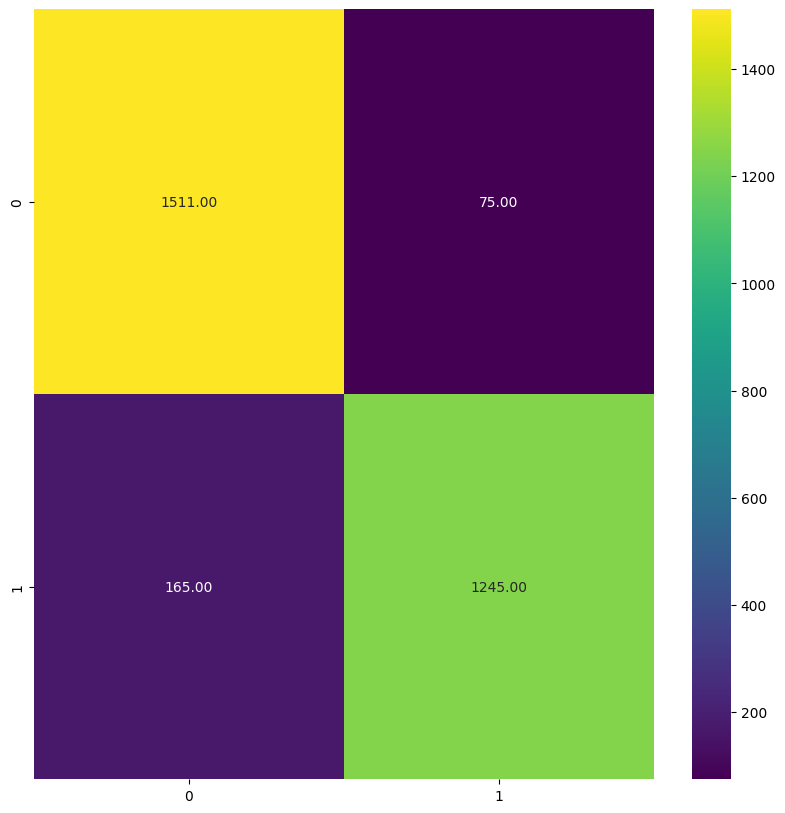

In [11]:
cm =confusion_matrix(y_true=y_test,y_pred=pred)
plt.figure(figsize=(10,10))
sns.heatmap(data =cm,annot=True,cmap="viridis",fmt=".2f")
plt.show()